<a href="https://colab.research.google.com/github/ChrisJavier/UIDE_2-WorkGroupDataScienceTools/blob/main/Week01/src/HDCGD_CP_W1_E2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Trabajo 1: Ejercicio de preparando y entendiendo los datos para la Predicción del cáncer de mama y ejercicio de Titanic

## 📋 Información del Proyecto
- Autores:
  - CARRERA DIAZ CHRISTIAN JAVIER
  - KEVIN YITZHACK AMBULUDI PATIÑO
  - ROMEL MICHAEL CERNA PACHECO
- Versión: 1.0.0
- Licencia: MIT


🎯 Introducción:

Utilice el dataset de cáncer de mama (Diagnostic Wisconsin Breast Cancer Database, WBCD) donde tenemos los datos de 569 mujeres. Cada mujer está descrita por 32 atributos. El primero es un identificador, el segundo el tipo de cáncer (Maligno o Benigno) y el resto son el resultado de otros análisis clínicos. Se pretende aprender el tipo de cáncer de mama (maligno=1, benigno=0). En este conjunto de datos la distribución de clases es: 357 benignos y 212 malignos.

Adicional, se adjunta el ejercicio de Titanic realizado en clase.

**🌍 Contexto del trabajo**

Esta práctica tiene el objetivo de realizar un preprocesamiento de datos y un Análisis exploratorio de datos (estadísticas y visualización) de las variables más relevantes que considere para el propósito de predicción de cáncer de mama. Al finalizar la práctica, los maestrantes podrán manipular adecuadamente un dataset de datos estructurados (alfanuméricos).

# 1️⃣ Fase 1: Análisis en Python:

*******************************************************************************

## 🔗 1.4. Enlaces del Dataset que se usaran

La información usada esta en la pagina oficial de datos para Maching Learning sobre Breast Cncer Wisconsin (Diagnostic)

- Dataset del registro muejeres con cancer de ceno de Wisconsin: http://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
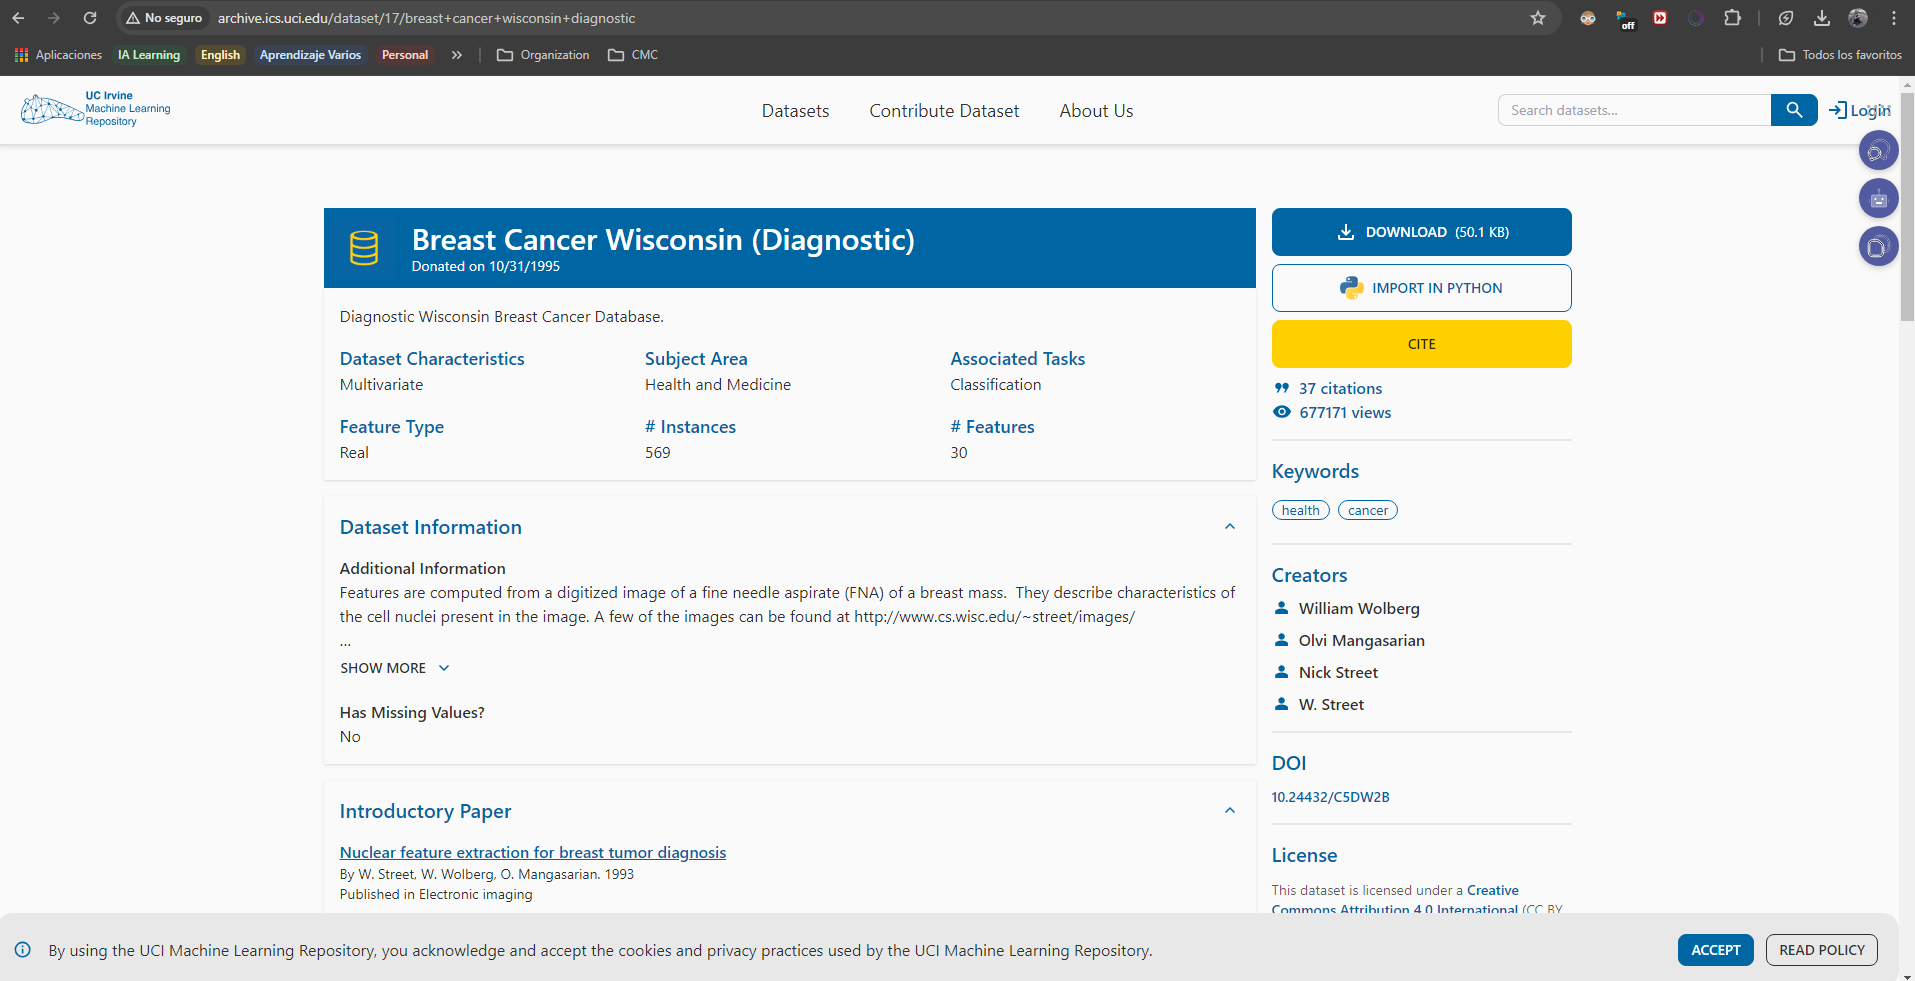

## 🚀 1.5. Descarga del dataset

El dataset contiene características se calculan a partir de una imagen digitalizada de una punción aspirativa con aguja fina (PAAF) de una masa mamaria. Describen las características de los núcleos celulares presentes en la imagen. Algunas de las imágenes se pueden encontrar en http://www.cs.wisc.edu/~street/images/ El plano de separación descrito anteriormente se obtuvo utilizando el Método de Árbol Multisuperficie (MSM-T) [KP Bennett, "Construcción de árboles de decisión mediante programación lineal." Actas de la 4.ª Sociedad de Inteligencia Artificial y Ciencias Cognitivas del Medio Oeste, págs. 97-101, 1992], un método de clasificación que utiliza programación lineal para construir un árbol de decisión. Las características relevantes se seleccionaron mediante una búsqueda exhaustiva en el espacio de 1 a 4 características y de 1 a 3 planos de separación. El programa lineal real utilizado para obtener el plano separador en el espacio tridimensional es el descrito en: [KP Bennett y OL Mangasarian: "Discriminación robusta mediante programación lineal de dos conjuntos linealmente inseparables

📥 Este código instala la libreria del sitio donde descargaremos el dataset:

In [1]:
!pip install ucimlrepo

In [2]:
 # importacion de la libreria os que permite interactuar con el sistema operativo (archivos y rutas)

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# Dataset para empezar el analisis
df = breast_cancer_wisconsin_diagnostic.data.original

# Mapeo de valores
mapeo = {
    'M': 1, # Maligno
    'B': 0 # Benigno
}

# Reemplazo de valores
df.Diagnosis = df.Diagnosis.map(mapeo)

# Conteo de datos en el dataset
df.Diagnosis.value_counts()

,count
Diagnosis,
0,357
1,212


## 🚀 1.6. Previsualizacion y validacion

📥 Se valida los datos que tenemos actualmente y visualizamos sus columnas y sus tipos de datos

In [3]:
# Visualizamos un breve informacion del dataset
df.info()

# Muestra un resumen estadístico de las columnas numéricas del dataset
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  569 non-null    int64  
 1   radius1             569 non-null    float64
 2   texture1            569 non-null    float64
 3   perimeter1          569 non-null    float64
 4   area1               569 non-null    float64
 5   smoothness1         569 non-null    float64
 6   compactness1        569 non-null    float64
 7   concavity1          569 non-null    float64
 8   concave_points1     569 non-null    float64
 9   symmetry1           569 non-null    float64
 10  fractal_dimension1  569 non-null    float64
 11  radius2             569 non-null    float64
 12  texture2            569 non-null    float64
 13  perimeter2          569 non-null    float64
 14  area2               569 non-null    float64
 15  smoothness2         569 non-null    float64
 16  compactn

,ID,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.372583
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,0.000000
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


## 🚀 1.7. Eliminación de columnas innecesarias

🔍 Eliminación  de la primera columna y validacion de datos perdidos

In [4]:
# Eliminamos la columna ID porque no se va utilizar para el analisis
df = df.drop("ID", axis=1)

# Visualizacion de los nuevos datos
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   perimeter1          569 non-null    float64
 3   area1               569 non-null    float64
 4   smoothness1         569 non-null    float64
 5   compactness1        569 non-null    float64
 6   concavity1          569 non-null    float64
 7   concave_points1     569 non-null    float64
 8   symmetry1           569 non-null    float64
 9   fractal_dimension1  569 non-null    float64
 10  radius2             569 non-null    float64
 11  texture2            569 non-null    float64
 12  perimeter2          569 non-null    float64
 13  area2               569 non-null    float64
 14  smoothness2         569 non-null    float64
 15  compactness2        569 non-null    float64
 16  concavit

## 🚀 1.8. Limpieza y Exploración Inicial:

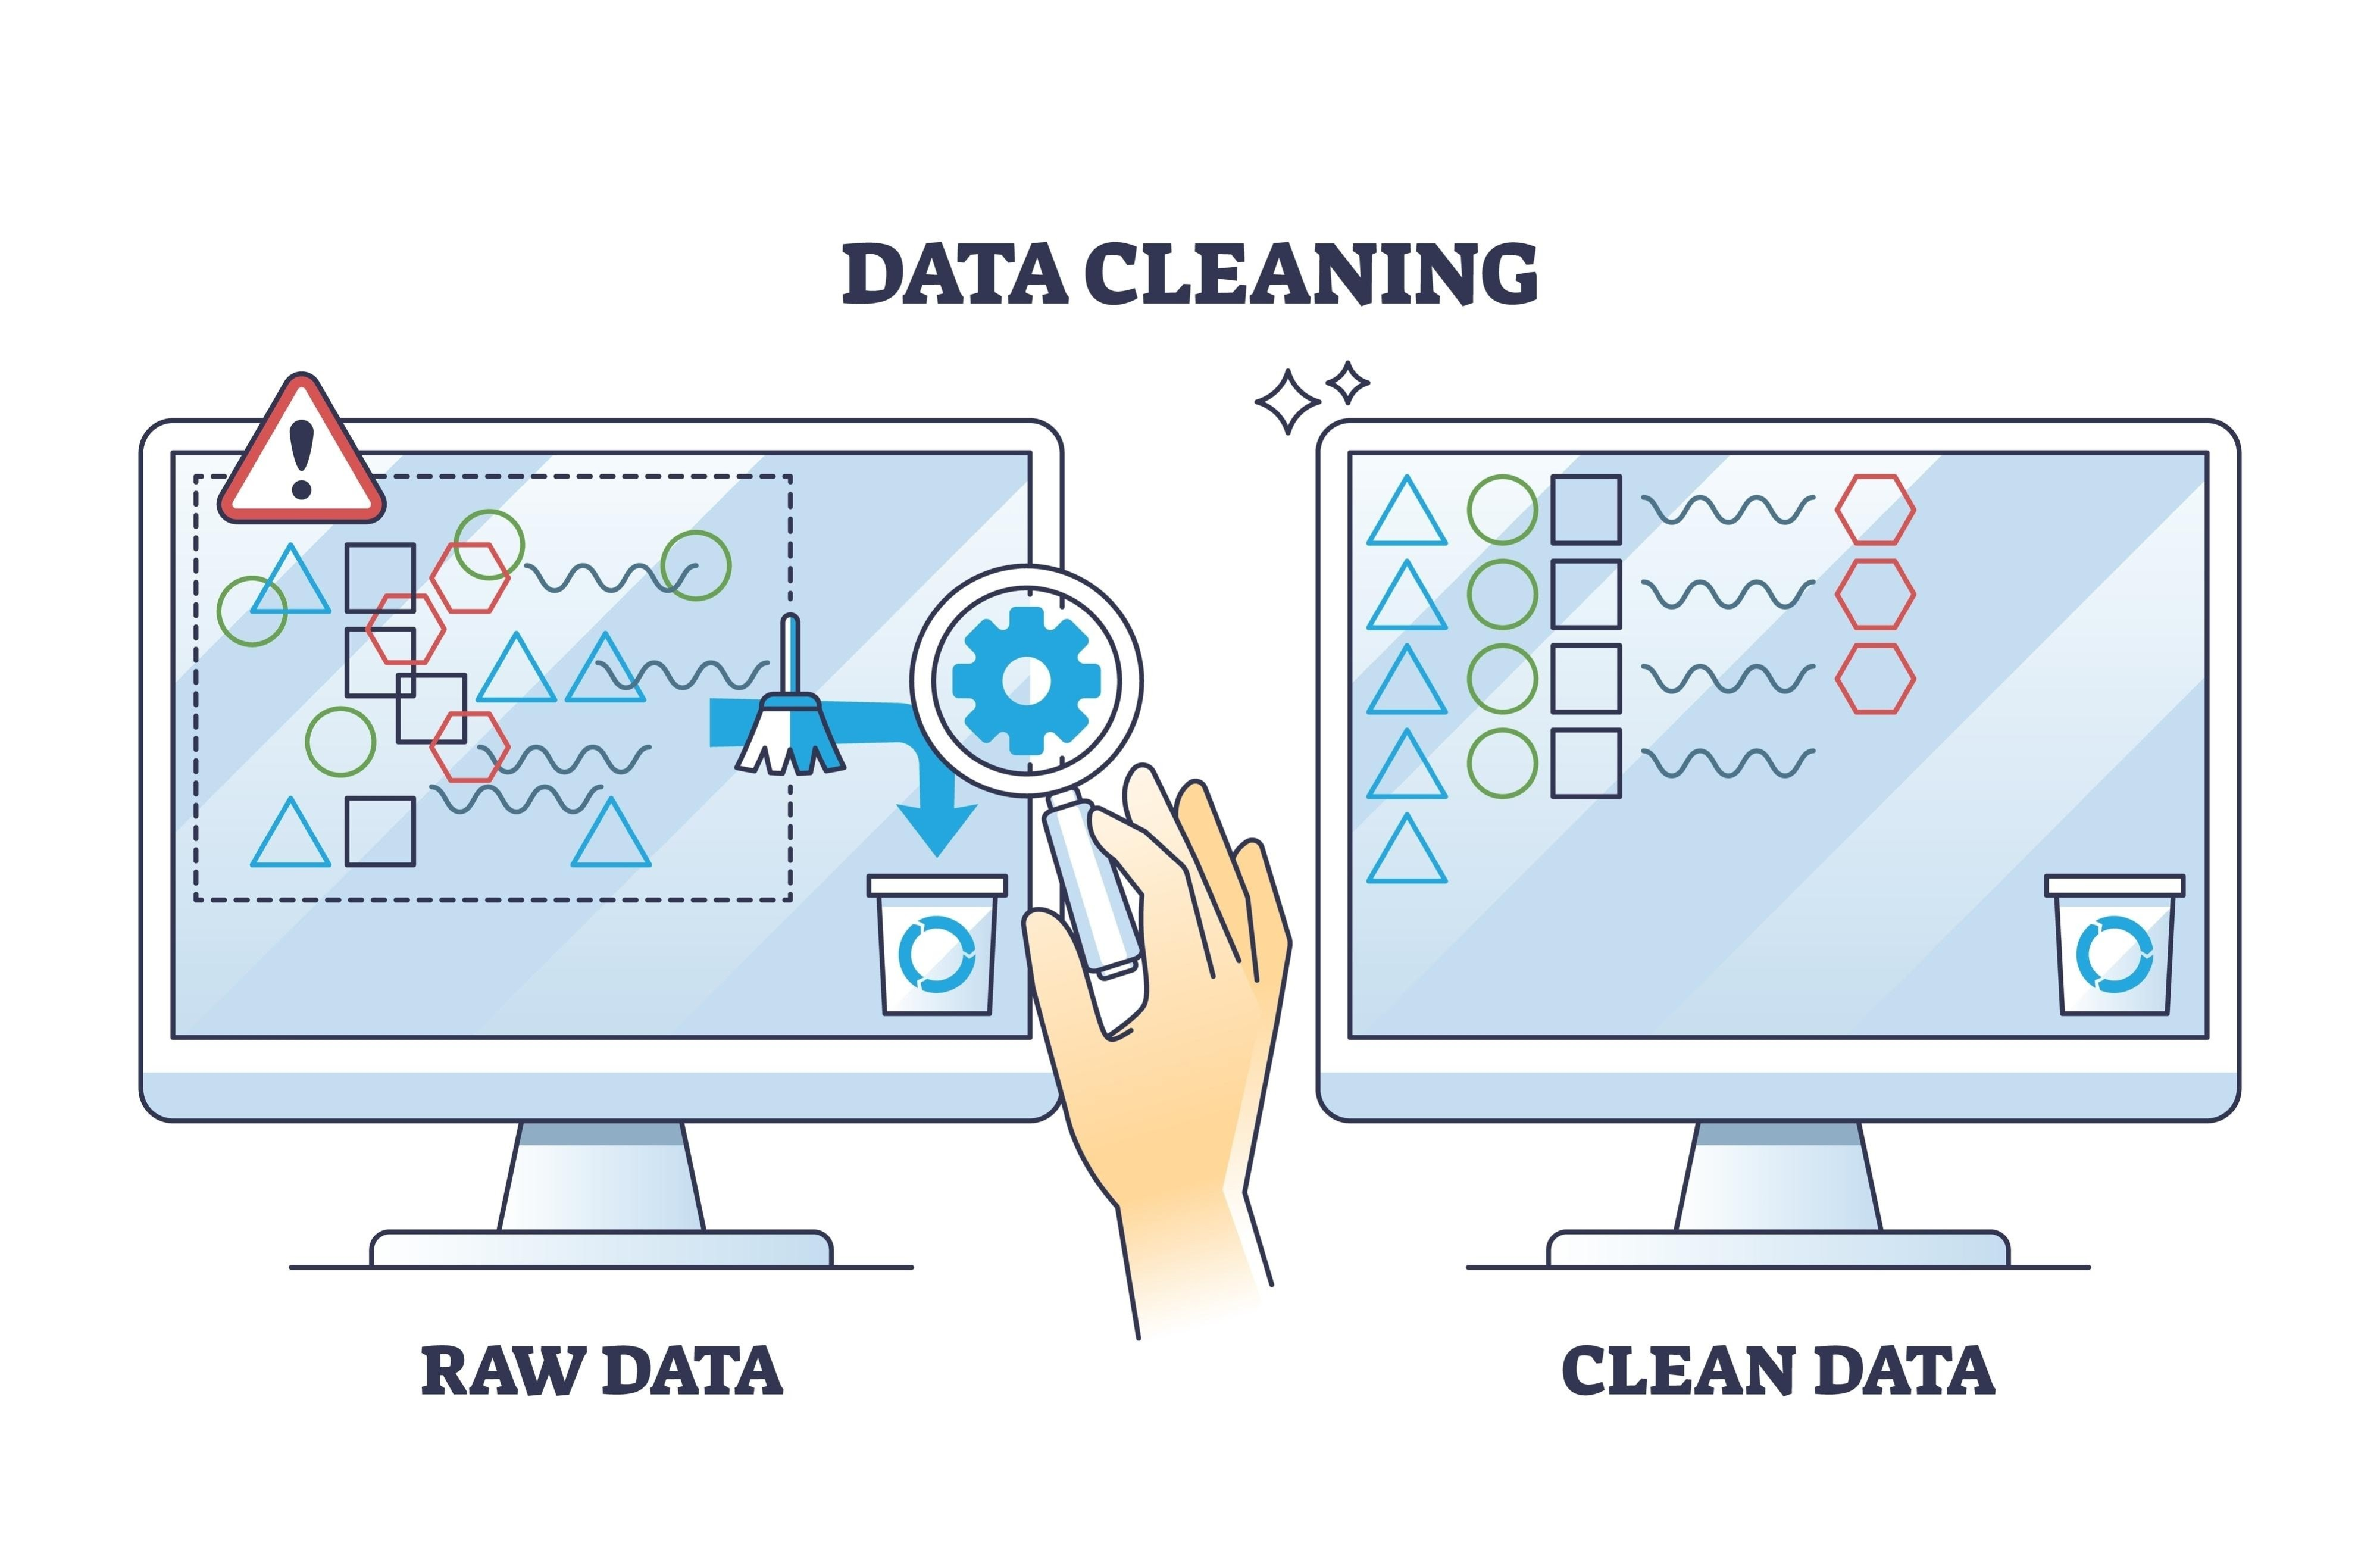

## 🚀 1.9. Tratamiento de Valores Nulos
Para garantizar que el análisis sea estadísticamente significativo y técnicamente eficiente, se han aplicado las siguientes reglas de procesamiento sobre el dataset:

Identificar las columnas que presentan más del 30 % de valores nulos para decidir su eliminación.
Adicional, se reviso las columnas por la varianza para eliminar aquellas que no sean necesarias.
En el caso de columnas críticas con pocos valores faltantes, se realiza la imputación de datos.

El código **analiza los valores nulos**, elimina las columnas con **más del 30 % de datos faltantes** y muestra un **comparativo del número de columnas antes y después** del proceso de limpieza.


In [5]:
# Obtiene el número total de columnas del DataFrame original
total_columnas_antes = df.shape[1]
total_columnas_antes  # Muestra el total de columnas antes del tratamiento

# Calcula el porcentaje de valores nulos por cada columna
nulos = (
    df.isna()          # Identifica valores nulos (NaN)
      .mean()          # Calcula la proporción de nulos por columna
      .mul(100)        # Convierte la proporción a porcentaje
      .round(2)        # Redondea a 2 decimales
      .reset_index()   # Convierte el índice en una columna
)

# Renombra las columnas del DataFrame resultante
nulos.columns = ['Columna', 'Porcentaje_nulos']

# Selecciona las columnas que tienen más del 30% de valores nulos
columnas_mayor_30 = (
    nulos[nulos['Porcentaje_nulos'] > 30]['Columna']
    .tolist()          # Convierte los nombres de columnas a una lista
)

# Elimina del DataFrame las columnas con más del 30% de nulos
df_reducido = df.drop(columns=columnas_mayor_30)

# "Las columnas que tienen un valor único... probablemente sean inútiles"
for col in df_reducido.columns:
    if df_reducido[col].nunique() == 1:
        print(f"Eliminando columna de varianza cero: {col}")
        df_reducido = df_reducido.drop(columns=[col])

print(f"Dimensiones post-limpieza básica: {df_reducido.shape}")

# Obtiene el total de columnas después de eliminar las columnas con muchos nulos
total_columnas_despues = df_reducido.shape[1]
total_columnas_despues  # Muestra el total de columnas después del tratamiento

# Crea un DataFrame resumen con el antes y después del tratamiento de columnas
resumen_columnas = pd.DataFrame({
    'Estado': ['Antes del tratamiento', 'Después del tratamiento'],
    'Total_columnas': [total_columnas_antes, total_columnas_despues]
})

# Muestra el resumen final
resumen_columnas


Dimensiones post-limpieza básica: (569, 31)


,Estado,Total_columnas
0,Antes del tratamiento,31
1,Después del tratamiento,31


Luego de validar, nos percatamos que no existen columnas para eliminar.

### Filtrado por Umbral de Nulos (30%)
Se decidió eliminar automáticamente cualquier columna que presentara más del 30% de valores ausentes.
###¿Por qué?:
Una columna con un alto índice de nulos introduce sesgos y reduce la confiabilidad de cualquier modelo o gráfico. Al superar el 30%, la cantidad de datos "inventados" o imputados necesarios para rellenar.

## 🚀 1.10. Normalizacion de datos

Como parte de este proyecto necesitamos normalizar los datos para mejorar la convergencia, estabilidad y rendimiento de un modelo. Sin embargo, para el analisis que estamos realizando nos ayudará a mejorar la interpretacion de los datos médicos.

In [6]:
# Según las recomendaciones investigadas y teniendo en cuenta que son datos médicos vamos a usar StandardScaler para modelos entrenados con regresión lineal

from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["Diagnosis"])
Y = df["Diagnosis"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Creamos un nuevo Dataset

df_train = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

# Revisamos el nuevo dataset
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   perimeter1          569 non-null    float64
 3   area1               569 non-null    float64
 4   smoothness1         569 non-null    float64
 5   compactness1        569 non-null    float64
 6   concavity1          569 non-null    float64
 7   concave_points1     569 non-null    float64
 8   symmetry1           569 non-null    float64
 9   fractal_dimension1  569 non-null    float64
 10  radius2             569 non-null    float64
 11  texture2            569 non-null    float64
 12  perimeter2          569 non-null    float64
 13  area2               569 non-null    float64
 14  smoothness2         569 non-null    float64
 15  compactness2        569 non-null    float64
 16  concavit


### 🧠 Interpretación

La normalización era necesaria porque las variables que tiene el dataset son de escalas heterogenéneas, es decir que tienen escalas más dispersas porque son datos clinicos y de cara a un modelo que se desea entrenar podria tener problemas debido a esas escalar que serán relevantes para el modelo pero no tiene que ser asi. Al ser sencibles a la magnitud es mejor normalizarlos a valores que puedan ser interpretados correctamente para una correcta predicción.

#2️⃣ Fase 2: Analisis Exploratorio (EDA) de Cáncer de Mama

En esta sección, vamos a realizar la interpretación de los datos proporcionados.

### 🚀 2.1. Matriz de correlacion

Generaremos una matriz de correlaccion con todas las columnas existentes en el dataset.

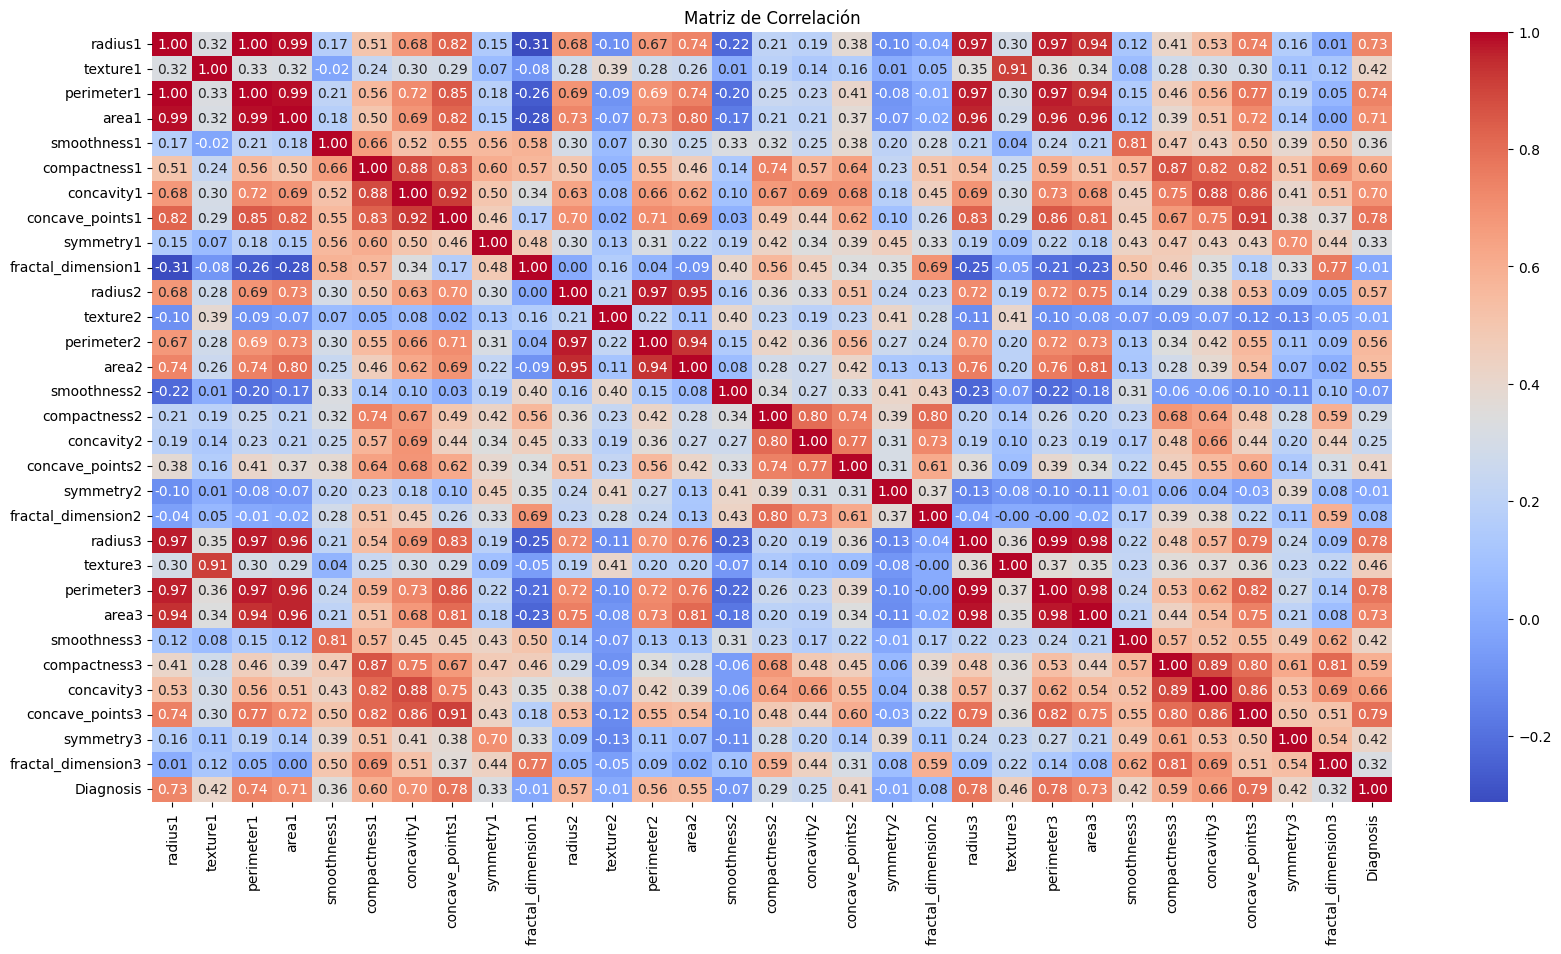

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns


# Crearemos una matriz de correlaccion entre los valores

corr_matrix = df.corr(numeric_only=True)


plt.figure(figsize=(20,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Matriz de Correlación")
plt.show()


### 🧠 Interpretación de Gráfico

El análisis de la matriz de correlación permitió identificar relaciones significativas entre las variables del dataset, evidenciando una fuerte dependencia entre características relacionadas con el tamaño y la forma de las células analizadas. Variables como radius, perimeter y area, especialmente en sus versiones 3 (worst), presentan correlaciones extremadamente altas entre sí, alcanzando valores cercanos a 1.00. Esto indica la presencia de multicolinealidad, ya que varias variables aportan información muy similar dentro del modelo.

Asimismo, se observó que las variables con mayor relación respecto al diagnóstico (Diagnosis) son concave_points3, perimeter3, radius3, area3 y concavity3, mostrando correlaciones positivas altas. Esto sugiere que las características geométricas más extremas o severas de las células tienen una fuerte influencia en la clasificación de tumores benignos y malignos, convirtiéndose en atributos relevantes para modelos predictivos.

Por otro lado, algunas variables como fractal_dimension2, smoothness2 y ciertas métricas de error presentan correlaciones bajas con el diagnóstico, lo que podría indicar una menor capacidad predictiva individual. En conjunto, la matriz confirma que el dataset posee patrones estructurados y consistentes, adecuados para aplicar técnicas de Machine Learning, aunque también evidencia la necesidad de considerar procesos de normalización y posible reducción de variables redundantes para optimizar el desempeño de los modelos.

### 🚀 2.2. Submatriz de correlacion

En esta submatriz tendremos filtrados las columnas con mayor correlacion para entender mejor este dataset.

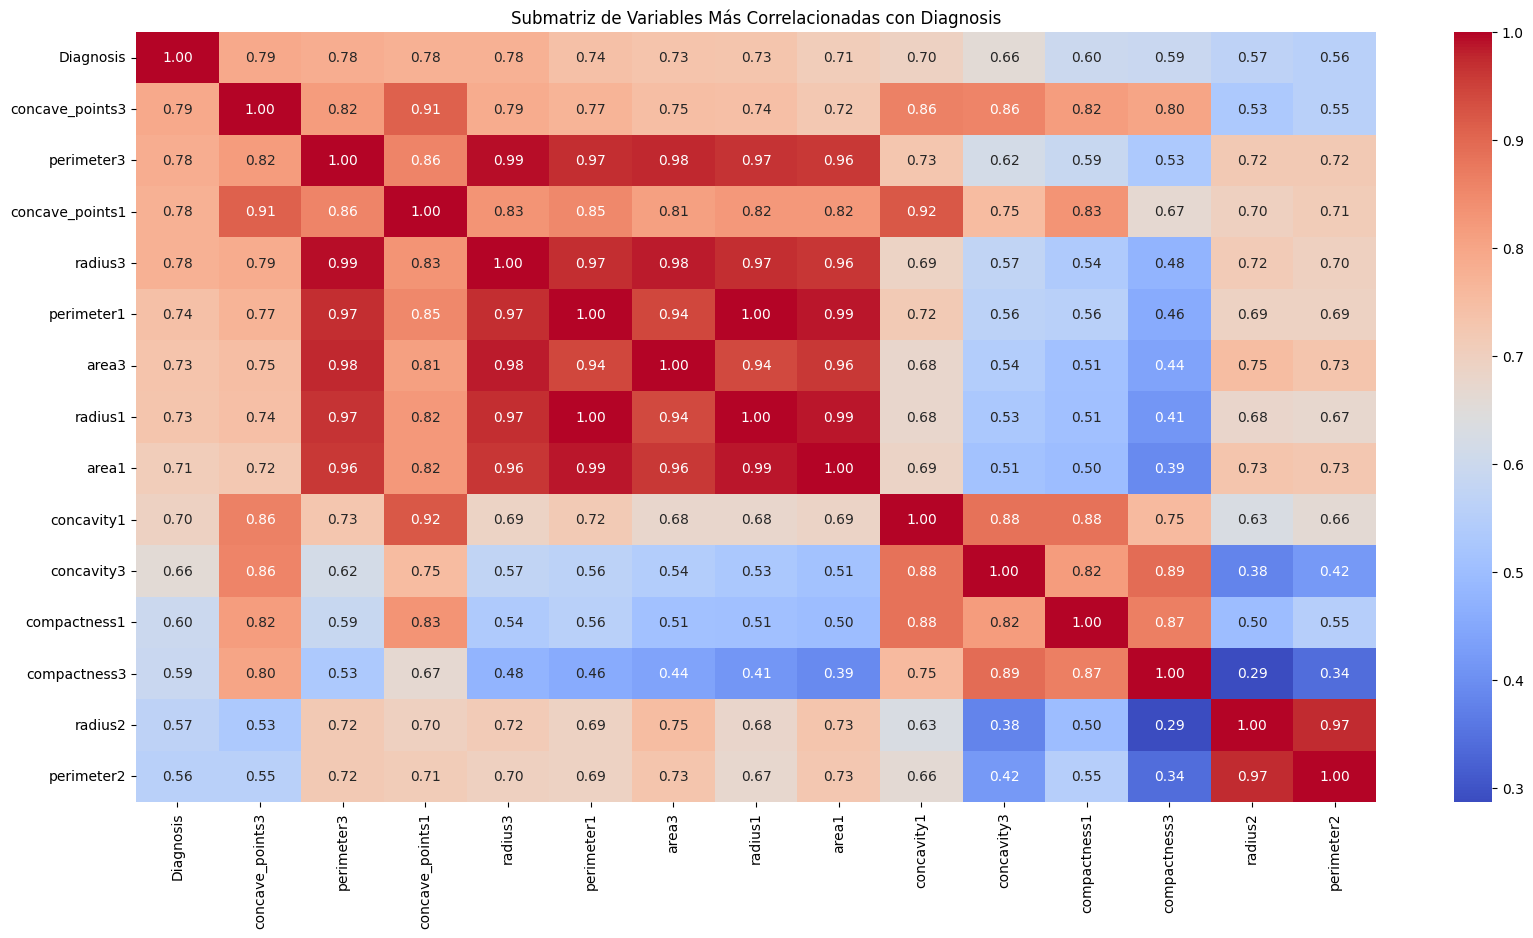

In [8]:
# Obtener correlación con Diagnosis
top_corr = (
    corr_matrix["Diagnosis"]
    .abs()
    .sort_values(ascending=False)
)

# Elegir top 10 variables
top_variables = top_corr.head(15).index

# Crear submatriz
submatriz = corr_matrix.loc[top_variables, top_variables]

# Graficar
plt.figure(figsize=(20,10))

sns.heatmap(
    submatriz,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Submatriz de Variables Más Correlacionadas con Diagnosis")
plt.show()

### 🧠 Interpretación de Gráfico

La submatriz de correlación permitió identificar una fuerte relación entre variables geométricas y morfológicas asociadas al diagnóstico. Las variables relacionadas con concavidad, perímetro y radio presentan las correlaciones más altas con tumores malignos, evidenciando un alto poder predictivo. Asimismo, se detectó multicolinealidad significativa entre variables de tamaño y forma, indicando redundancia de información y la necesidad de aplicar técnicas de selección o reducción de variables para optimizar futuros modelos de Machine Learning.

### 🚀 2.3. Distribución de clases

En este gráfico verificaremos si hay desbalance en los casos por el diagnostico.

/tmp/ipykernel_194/3441091432.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Benigno", "Maligno"])


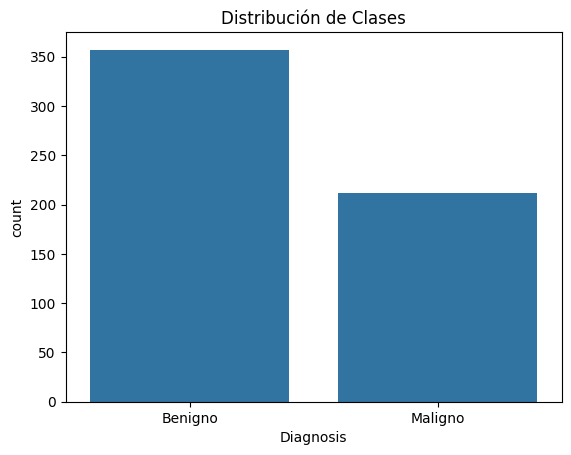

In [9]:
# Veremos un gráfico de los casos (Conteo automático)
ax = sns.countplot(
    data=df,
    x="Diagnosis"
)

# Cambiar etiquetas del eje X
ax.set_xticklabels(["Benigno", "Maligno"])

plt.title("Distribución de Clases")
plt.show()

### 🧠 Interpretación de Gráfico

En este gráfico no se ve ninguna diferencia con respecto a la información de antes. Donde los tumores Benignos son mayores respecto a los Malignos

### 🚀 2.4. Boxplots por diagnóstico

En este gráfico observaremos si los tumores malignos tienen mayor tamaño, más irregularidad o mayor concavidad que clínicamente es muy útila.

/tmp/ipykernel_194/722999884.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Benigno", "Maligno"])


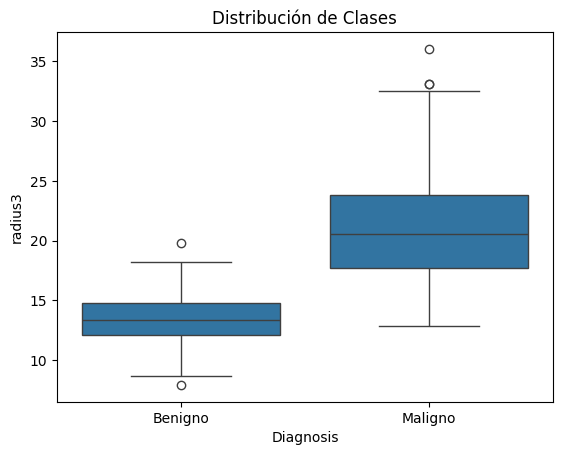

In [10]:
# Gráficaremos el boxplot por la columna Diagnosis

ax = sns.boxplot(
    x="Diagnosis",
    y="radius3",
    data=df
)

# Cambiar etiquetas del eje X
ax.set_xticklabels(["Benigno", "Maligno"])

plt.title("Distribución de Clases")
plt.show()

### 🧠 Interpretación de Gráfico

Los tumores malignos son notablemente más grandes: La caja de "Maligno" está ubicada mucho más arriba en el eje vertical que la de "Benigno". Esto significa que el radio (radius3) de los tumores malignos tiende a ser mayor.

La diferencia de medianas: La mediana del grupo benigno está cerca de 13, mientras que la del grupo maligno supera los 20.

La variabilidad y dispersión: La caja "Maligno" es mucho más alta que la "Benigno". Esto nos indica que el tamaño de los tumores malignos es muy variado (cambia mucho de un paciente a otro), mientras que los benignos son más homogéneos y estables en su tamaño pequeño.

Además, poco solapamiento: Las dos cajas casi no se cruzan en el eje vertical. Esto demuestra que la variable radius3 es un excelente predictor para ayudar a clasificar o diagnosticar si un tumor es benigno o maligno.

### 🚀 2.5. Detección de Outliers

En este gráfico observaremos los posibles outliers o valores atípicos que podremos encontrar en el dataset

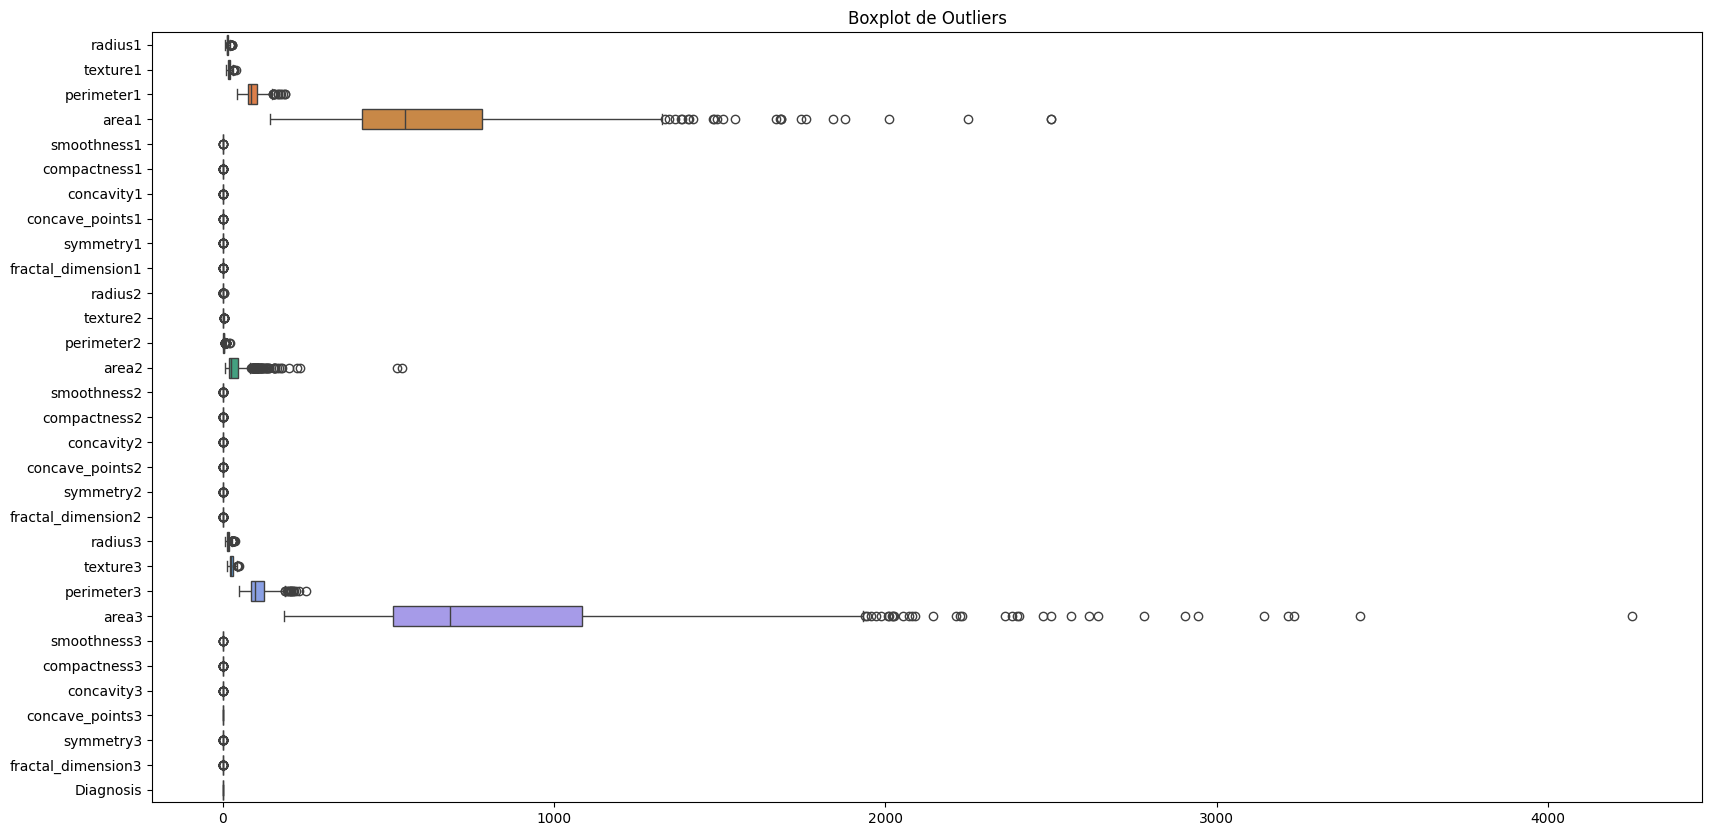

In [11]:
# Gráfico de outliers
plt.figure(figsize=(20, 10))

sns.boxplot(
    data=df,
    orient="h"
)

plt.title("Boxplot de Outliers")
plt.show()

### 🧠 Interpretación de Gráfico

Como se observa en el gráfico los valores atípicos se pueden visualizar mejor en las columnas area1, area2, area3 y perimeter3. Tenemos mayores valores en area1 y area 3 que sobrepsan a partir de 1500 que nos puede dar a interpretacion que tenemos tumores más grandes por el área que fue registrada pero también pueden interpretarse como valores medidos incorrectamente o errores en las capturas. Sin embargo, nosmuestra al menos una idea de los tumores que se pudieron capturar entre las pacientes y puede ser detectadas por el area.

Finalmente, el resto de mediciones notamos que son muy parecidos que no serian relevantes para un analisis de outliers pero esto puede ayudar validar otros patrones en este diagnostico de los datos.

### 🚀 2.6. Pairplot de relaciones entre diagnosticos

En este gráfico observaremos las relaciones entre varibles y separación visual de clases.

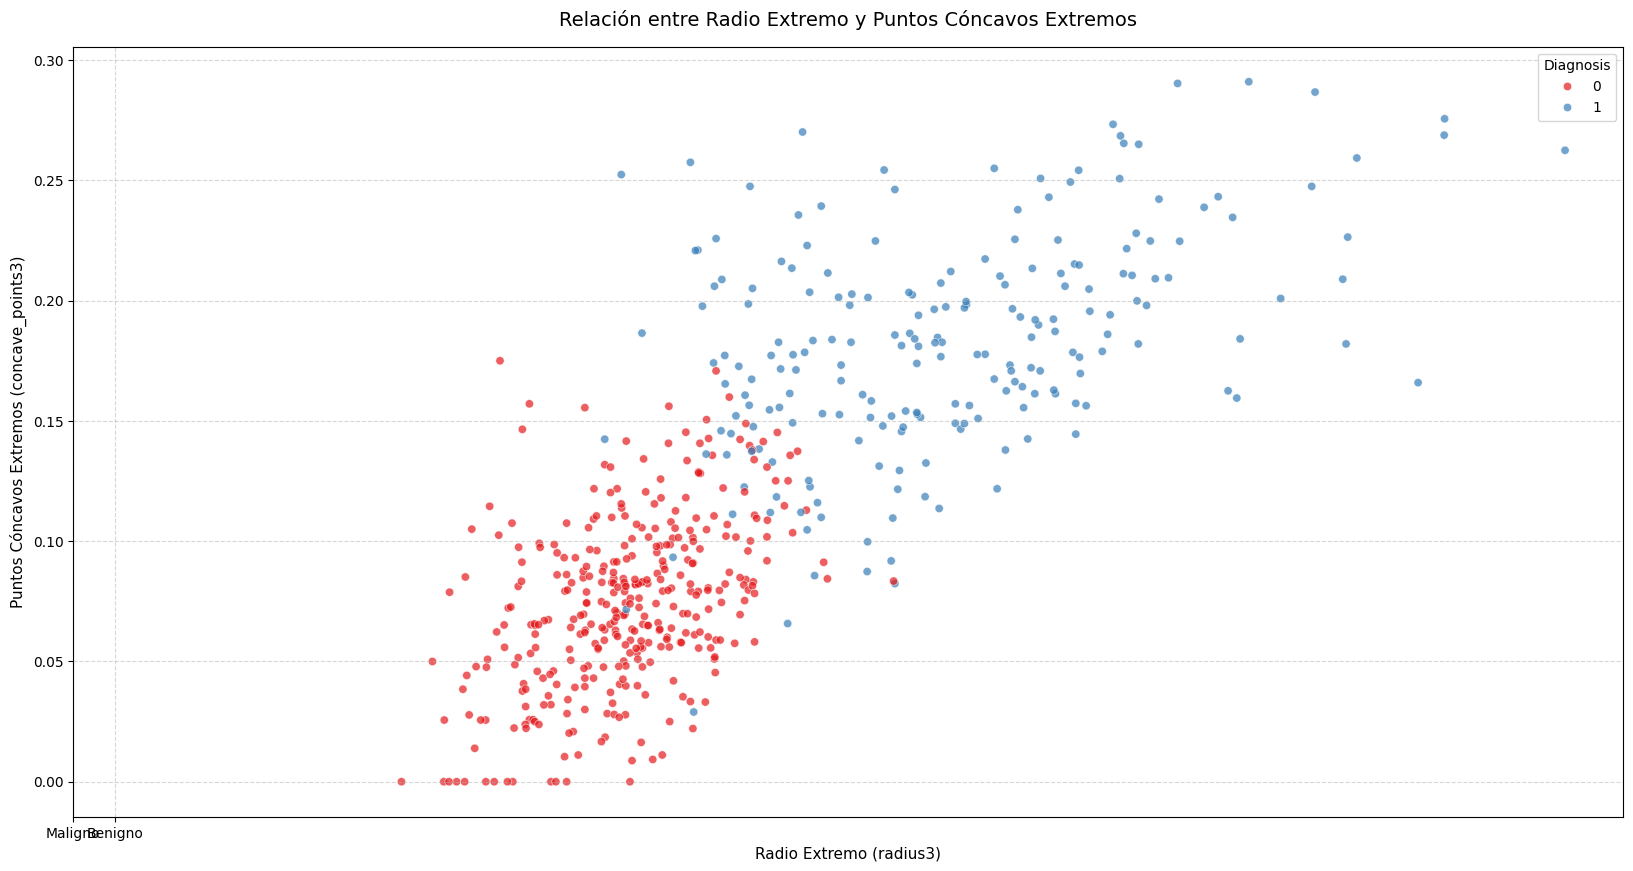

In [12]:
# Gráfico de pairplot

plt.figure(figsize=(20, 10))

ax = sns.scatterplot(
    data=df,
    x="radius3",
    y="concave_points3",
    hue="Diagnosis",
    palette="Set1", # Colores claros para contrastar benigno/maligno
    alpha=0.7
)
ax.set_xticks([0, 1])
# Luego le asignamos los nombres de texto correspondientes
ax.set_xticklabels(["Maligno", "Benigno"])

plt.title("Relación entre Radio Extremo y Puntos Cóncavos Extremos", fontsize=14, pad=15)
plt.xlabel("Radio Extremo (radius3)", fontsize=11)
plt.ylabel("Puntos Cóncavos Extremos (concave_points3)", fontsize=11)

plt.grid(True, linestyle="--", alpha=0.5) # Malla opcional para mejor lectura
plt.show()

### 🧠 Interpretación de Gráfico

Existe un patrón visual evidente que divide a ambos grupos. Los tumores benignos (rojos) se agrupan firmemente en la zona inferior izquierda, mientras que los malignos (azules) se desplazan hacia la zona superior derecha. En ambos casos, a mayor radio extremo (radius3), también aumentan los puntos cóncavos extremos (concave_points3). Sin embargo, este crecimiento es mucho más marcado y agresivo en el grupo maligno.Variables con alto poder predictivo: Debido a que hay muy pocas áreas donde los puntos rojos y azules se mezclan (zona de solapamiento baja), ambas variables son excelentes candidatas para entrenar un modelo de Machine Learning (como una regresión logística o SVM). Un algoritmo podrá trazar una línea diagonal para separar ambas clases con alta precisión. Si un paciente presenta un radius3 mayor a 15 y un concave_points3 superior a 0.10, la probabilidad estadística de que el tumor sea maligno es extremadamente alta.

# 3️⃣ Fase 3: Conclusiones del proceso y análisis de datos para cancer de mama

Agregue sus conclusiones, desarrollando un análisis integral de todo el proceso
realizado. En su reflexión, identifique y explique:

## 🚀 3.1. ¿Qué podemos concluir en base al analisis realizado?


## ⭐ Respuesta

En base al análisis exploratorio realizado sobre el dataset de cáncer de mama, se concluye que existen patrones claros y consistentes entre las características geométricas de las células y el diagnóstico de tumores benignos o malignos. Variables como radius, perimeter, area, concavity y concave_points mostraron una alta correlación con el diagnóstico, indicando que el tamaño, la irregularidad y la forma de las células son factores relevantes para la detección del cáncer.

Asimismo, la matriz de correlación permitió identificar una fuerte multicolinealidad entre varias variables, especialmente aquellas relacionadas con medidas de tamaño y forma. Esto evidencia redundancia de información dentro del dataset, por lo que sería recomendable aplicar técnicas de selección o reducción de variables para optimizar futuros modelos predictivos y mejorar la eficiencia del análisis.

Finalmente, los resultados demuestran que el dataset posee una estructura adecuada para aplicar técnicas de Machine Learning, ya que presenta relaciones significativas entre variables y patrones diferenciables entre tumores benignos y malignos. Esto confirma el potencial del análisis de datos y la inteligencia artificial como herramientas de apoyo en el diagnóstico temprano y la toma de decisiones médicas relacionadas con el cáncer de mama.



# 4️⃣ Fase 4: Analisis de datos de Titanic

In [13]:
# importacion de la libreria os que permite interactuar con el sistema operativo (archivos y rutas)

import os

# Define el nombre del archivo comprimido que se descargará
population_file_path = 'titanic.csv'

# Descarga el archivo CSV

if not os.path.exists(population_file_path):
  !wget --timeout=15 --tries=2 'https://raw.githubusercontent.com/ChrisJavier/UIDE_2-WorkGroupDataScienceTools/refs/heads/main/Week01/doc/titanic.csv' -O '{population_file_path}'

# Leer el archivo CSV
titanic_df = pd.read_csv(population_file_path)

# Ver las primeras filas del conjunto de datos
print(titanic_df.head())

--2026-05-20 02:11:20--  https://raw.githubusercontent.com/ChrisJavier/UIDE_2-WorkGroupDataScienceTools/refs/heads/main/Week01/doc/titanic.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 60302 (59K) [text/plain]
Saving to: ‘titanic.csv’

titanic.csv         100%[===================>]  58.89K  --.-KB/s    in 0.04s   

2026-05-20 02:11:20 (1.53 MB/s) - ‘titanic.csv’ saved [60302/60302]

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cu

# 5️⃣ Fase 5: Analisis Exploratorio (EDA) de Titanic

## 🚀 5.1. Descripción de datos

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  
                       Name   Sex  Ticket Cabin Embarked
count                   

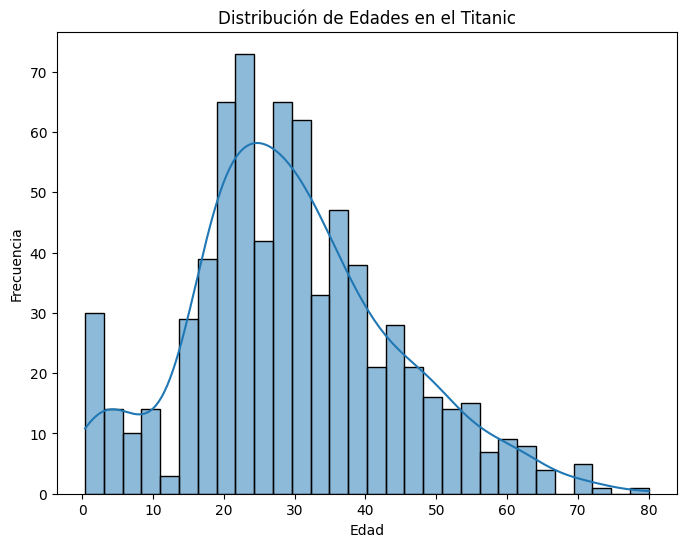

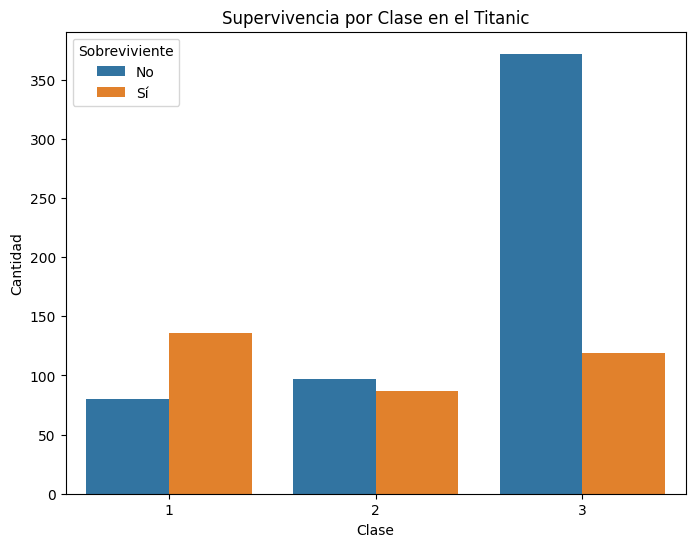

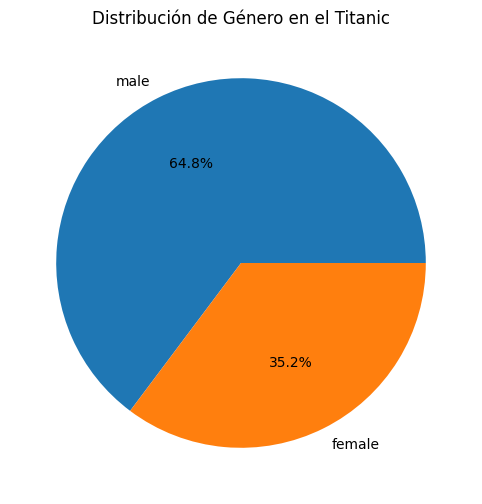

In [14]:
# Estadísticas descriptivas
print(titanic_df.describe())

# Estadísticas de variables categóricas
print(titanic_df.describe(include=['object']))

# Histogramas de Edades:
plt.figure(figsize=(8, 6))
sns.histplot(titanic_df['Age'].dropna(), bins=30, kde=True)
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.title('Distribución de Edades en el Titanic')
plt.show()

# Gráfico de Barras de Supervivencia por Clase:
plt.figure(figsize=(8, 6))
sns.countplot(data=titanic_df, x='Pclass', hue='Survived')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.title('Supervivencia por Clase en el Titanic')
plt.legend(title='Sobreviviente', labels=['No', 'Sí'])
plt.show()

# Gráfico de Torta de Género:
plt.figure(figsize=(8, 6))
titanic_df['Sex'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribución de Género en el Titanic')
plt.ylabel('')
plt.show()


### 🧠 Interpretación de Gráfico

Los gráficos revelan que la población a bordo del Titanic era mayoritariamente masculina (64.8%) y que la supervivencia estuvo directamente condicionada por la clase social del boleto. La primera clase fue la única donde el número de sobrevivientes superó al de fallecidos, mientras que la tercera clase sufrió el mayor impacto de la tragedia con una pérdida masiva que superó los 350 pasajeros, evidenciando una marcada desigualdad en el rescate.

## 🚀 5.2. Correlacion

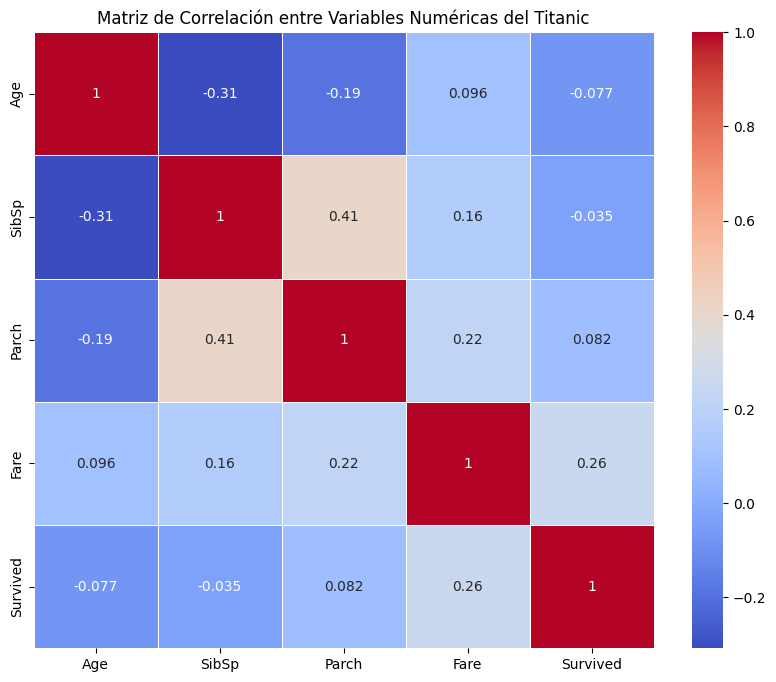

In [15]:
# Análisis de Correlación
# Se podría eliminar aquellas variables que tengan una correlación baja o nula
# con la variable objetivo, ya que podrían no aportar información relevante al modelo.
# Además, se podría quitar ciertas variables que están altamente correlacionadas entre sí.

# Seleccionar las variables numéricas principales para el análisis de correlación y el target
variables_numericas = ['Age', 'SibSp', 'Parch', 'Fare', 'Survived']

# Crear una submatriz de correlación
correlation_matrix = titanic_df[variables_numericas].corr()

# Crear un mapa de calor de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Matriz de Correlación entre Variables Numéricas del Titanic')
plt.show()

### 🧠 Interpretación de Gráfico

La matriz de correlación revela que las relaciones lineales entre las variables del Titanic son en su mayoría débiles, destacando únicamente la asociación positiva de 0.41 entre SibSp y Parch, lo que indica que los pasajeros acompañados solían viajar con núcleos familiares completos (parejas, hermanos e hijos). En cuanto a la supervivencia (Survived), la variable con mayor influencia positiva es la tarifa pagada (Fare con 0.26), confirmando estadísticamente que un boleto de mayor costo incrementaba las posibilidades de salvarse, mientras que la edad (Age) presenta una correlación ligeramente negativa (-0.077), lo que refleja una mínima tendencia de prioridad de rescate hacia los pasajeros más jóvenes.

## 🚀 5.3. Diagrama de Caja

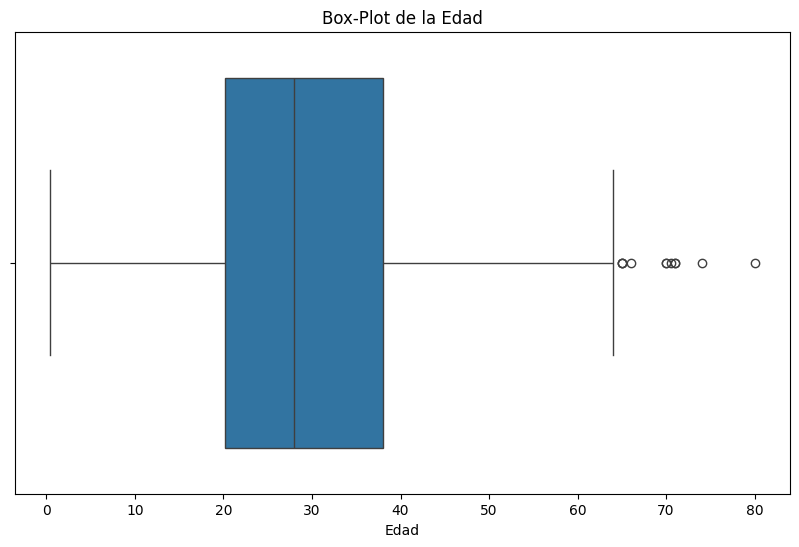

In [16]:
# Crear el box-plot de la variable "edad"
plt.figure(figsize=(10, 6))
sns.boxplot(x=titanic_df['Age'])
plt.title('Box-Plot de la Edad')
plt.xlabel('Edad')
plt.show()

### 🧠 Interpretación de Gráfico

El diagrama de caja (Box-Plot) de la edad muestra que la población de pasajeros era predominantemente joven, con una mediana de edad cercana a los 28 años y el 50% central de los datos concentrado en un rango de entre los 20 y los 38 años. La distribución se extiende desde bebés recién nacidos hasta un límite normal de unos 64 años, identificando además varios valores atípicos (outliers) en el extremo derecho que corresponden a un grupo reducido de pasajeros de edad avanzada que oscilan entre los 65 y los 80 años.

# 6️⃣ Fase 6: Aplicación en Entorno Laboral

## 🚀 Redacta una sección final de aplicación:
- Cada miembro del equipo colocara su nombre una explicación de como aplicaría
lo aprendido en esta semana en su entorno profesional.

# 🖥️ **ROMEL MICHAEL CERNA PACHECO**
La aplicación del preprocesamiento y del análisis exploratorio de datos (EDA), combinada con el análisis del negocio, proporciona información valiosa para definir futuros planes de acción. Esto permite comprender las métricas clave y las variables más relevantes que contribuyen a alcanzar los objetivos planteados. Tanto en casos prácticos como en entornos laborales, estos análisis sirven como base para impulsar la mejora continua mediante indicadores de gestión (KPIs) que orienten la toma de decisiones y ayuden a identificar el origen de los problemas.

# 🖥️ **Christian Carrera**
El análisis de datos y las técnicas de Machine Learning permiten identificar patrones relevantes para mejorar la toma de decisiones en entornos reales. En un entorno laboral, estos procesos pueden aplicarse para detectar anomalías, optimizar reportes, automatizar análisis y generar información más precisa para apoyar decisiones estratégicas basadas en datos.